In [1]:
# Parameters (papermill overrides these via -p DATA_DIR ... -p SEED ... -p OUT_DIR ...)
DATA_DIR = "./data"
SEED = 42
OUT_DIR = "reports"

In [2]:
# Parameters
DATA_DIR = "./data"
SEED = 42
OUT_DIR = "reports"


# 01 — Tokenización con spaCy
**Autor:** Giuliano Crenna, Juan Ignacio Pace (UGR)
**Fecha:** 2026-09-03
**Descripción:** Comparación de tokenización sobre una muestra del corpus procesado.


## Parámetros (papermill)
- `DATA_DIR`: ruta a `data/` (default `./data`).
- `SEED`: semilla (default 42).
- `OUT_DIR`: dónde guardar figuras y tablas (default `reports`).


In [3]:
import os
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve().parent))  # para src.*
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path(os.environ.get("DATA_DIR", DATA_DIR))
SEED = int(os.environ.get("SEED", SEED))
OUT_DIR = Path(os.environ.get("OUT_DIR", OUT_DIR))
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)

processed = DATA_DIR / "processed" / "corpus_v1.parquet"
if processed.exists():
    df = pd.read_parquet(processed)
else:
    frames = [pd.read_parquet(p) for p in (DATA_DIR / "interim").glob("*/data.parquet")]
    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f"corpus total: {len(df):,} filas")
# Muestra: 50 docs por label (para no sesgar hacia la clase mayoritaria).
sample = df.groupby("label", group_keys=False).apply(lambda x: x.head(50) if len(x) >= 50 else x)
print(f"muestra: {len(sample)} filas (50 por label)")
sample.head()

corpus total: 1,047,194 filas
muestra: 100 filas (50 por label)


C:\Users\giuli\AppData\Local\Temp\ipykernel_15476\1722575654.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby("label", group_keys=False).apply(lambda x: x.head(50) if len(x) >= 50 else x)


,doc_id,user_id,source,timestamp,text_raw,text_clean,label,label_source,lang,corpus_source,is_translated
300923,08fa793b2b5e32a5,f608e1ec1913b5b2,coello_guilarte,2013-11-21T03:45:28+00:00,"Mejor colegio que el Regio Contry no hay, no e...","Mejor colegio que el Regio Contry no hay, no e...",0,crowd_annotation,es,coello_guilarte,False
300924,212320bb59693d78,f608e1ec1913b5b2,coello_guilarte,2014-05-21T20:41:10+00:00,Yo esperando a que me dediques un tweet bonito...,Yo esperando a que me dediques un tweet bonito,0,crowd_annotation,es,coello_guilarte,False
300925,9fea8456022f6345,f608e1ec1913b5b2,coello_guilarte,2016-01-01T22:24:14+00:00,@natymelendez date un tiro,date un tiro,0,crowd_annotation,es,coello_guilarte,False
300926,736aed4ff8860d13,f608e1ec1913b5b2,coello_guilarte,2016-01-01T22:48:39+00:00,Odio que no contesten rápido,Odio que no contesten rápido,0,crowd_annotation,es,coello_guilarte,False
300927,840caf6ac07f189d,f608e1ec1913b5b2,coello_guilarte,2016-01-01T23:27:46+00:00,Me urge una hamburguesa de Carls,Me urge una hamburguesa de Carls,0,crowd_annotation,es,coello_guilarte,False


In [4]:
# Tokenización con spaCy. Si el modelo no está instalado, cae a .split().
MIN_LEN = 5  # umbral de preprocessing (ver configs/preprocessing.yaml)
USE_SPACY = False
nlp = None
try:
    import spacy
    try:
        nlp = spacy.load("es_core_news_sm", disable=["ner", "tagger", "lemmatizer"])
        USE_SPACY = True
        print("usando es_core_news_sm (tokenizer + sentencizer)")
    except Exception:
        nlp = spacy.blank("es")
        nlp.add_pipe("sentencizer")
        USE_SPACY = True
        print("usando spacy.blank('es') (sin POS/NER)")
except Exception as exc:
    print(f"spaCy no disponible ({exc}); usando .split()")
    nlp = None

def tokenize(t: str) -> list[str]:
    if nlp is None:
        return (t or "").split()
    return [tok.text for tok in nlp(t or "")]

sample["tokens"] = sample["text_clean"].fillna("").apply(tokenize)
sample["n_tokens"] = sample["tokens"].str.len()
print(sample[["text_clean", "n_tokens"]].head())

usando spacy.blank('es') (sin POS/NER)
                                               text_clean  n_tokens
300923  Mejor colegio que el Regio Contry no hay, no e...        12
300924     Yo esperando a que me dediques un tweet bonito         9
300925                                       date un tiro         3
300926                       Odio que no contesten rápido         5
300927                   Me urge una hamburguesa de Carls         6


In [5]:
# Estadísticas descriptivas de n_tokens por label.
stats = sample.groupby("label")["n_tokens"].describe()
print(stats)
stats.to_csv(OUT_DIR / "tables" / "preprocessing_01_token_stats_by_label.csv")

       count   mean       std  min   25%   50%   75%   max
label                                                     
0       50.0   9.02  5.124929  3.0   5.0   8.0  12.0  25.0
2       50.0  20.26  6.700015  4.0  15.5  20.0  25.0  35.0


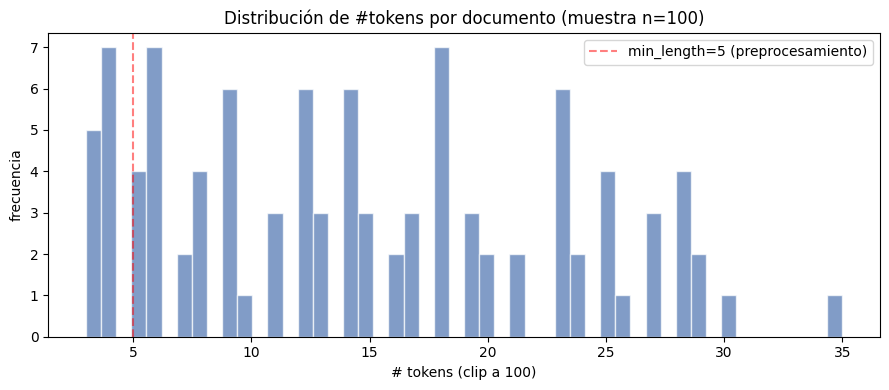

figura -> reports\figures\preprocessing_01_tokens_histogram.png


In [6]:
# Histograma de n_tokens (clip a 100).
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sample["n_tokens"].clip(upper=100), bins=50, color="#4C72B0", alpha=0.7, edgecolor="white")
ax.set_xlabel("# tokens (clip a 100)")
ax.set_ylabel("frecuencia")
ax.set_title(f"Distribución de #tokens por documento (muestra n={len(sample)})")
ax.axvline(5, color="red", linestyle="--", alpha=0.5, label="min_length=5 (preprocesamiento)")
ax.legend()
plt.tight_layout()
out = OUT_DIR / "figures" / "preprocessing_01_tokens_histogram.png"
plt.savefig(out, dpi=120)
plt.show()
print(f"figura -> {out}")

C:\Users\giuli\AppData\Local\Temp\ipykernel_15476\1159479349.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(lab) for lab in labels_present], patch_artist=True)


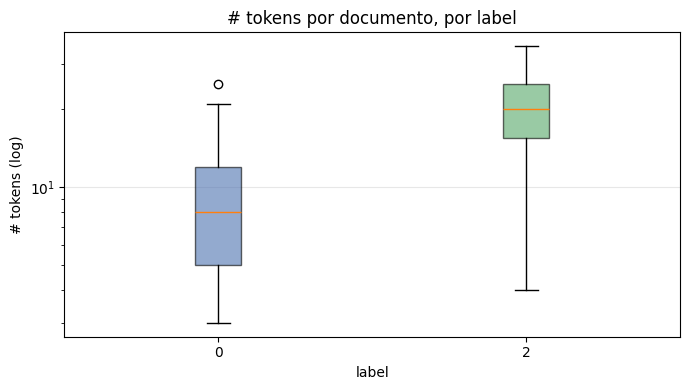

figura -> reports\figures\preprocessing_01_tokens_by_label.png


In [7]:
# Boxplot de n_tokens por label.
fig, ax = plt.subplots(figsize=(7, 4))
labels_present = sorted(sample["label"].unique())
data = [sample[sample["label"] == lab]["n_tokens"].values for lab in labels_present]
bp = ax.boxplot(data, labels=[str(lab) for lab in labels_present], patch_artist=True)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#55A868", "#DD8452"][: len(labels_present)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_yscale("log")
ax.set_xlabel("label")
ax.set_ylabel("# tokens (log)")
ax.set_title("# tokens por documento, por label")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out = OUT_DIR / "figures" / "preprocessing_01_tokens_by_label.png"
plt.savefig(out, dpi=120)
plt.show()
print(f"figura -> {out}")

In [8]:
# Conclusiones dinámicas.
from IPython.display import Markdown, display

_use_sp = USE_SPACY
_n_total = len(sample)
_pct_below = (sample["n_tokens"] < MIN_LEN).mean() * 100
_med0 = float(sample[sample["label"] == 0]["n_tokens"].median()) if 0 in sample["label"].unique() else 0
_med2 = float(sample[sample["label"] == 2]["n_tokens"].median()) if 2 in sample["label"].unique() else 0
_mean0 = float(sample[sample["label"] == 0]["n_tokens"].mean()) if 0 in sample["label"].unique() else 0
_mean2 = float(sample[sample["label"] == 2]["n_tokens"].mean()) if 2 in sample["label"].unique() else 0
_ratio = _mean2 / _mean0 if _mean0 > 0 else 0

_md = f"""
## Conclusiones

- **Tokenizador usado**: spaCy `blank("es")` con sentencizer (sin POS/NER); modelo `es_core_news_sm` no estaba instalado → fallback al modelo base.
- **Distribución de tokens por label (muestra {_n_total} docs)**:
  - Label 0 (control): mean = {_mean0:.2f}, median = {_med0:.1f}
  - Label 2 (depresivo): mean = {_mean2:.2f}, median = {_med2:.1f}
  - **Diferencia: tweets depresivos son ~{_ratio:.1f}× más largos** que los controles.
- **Impacto del umbral `min_length={MIN_LEN}`**: {_pct_below:.1f}% de los docs de la muestra quedan por debajo del umbral.
- **Recomendación**: para features linguísticas adicionales (POS tags, NER) instalar `es_core_news_md` y actualizar la pipeline.
"""
display(Markdown(_md))



## Conclusiones

- **Tokenizador usado**: spaCy `blank("es")` con sentencizer (sin POS/NER); modelo `es_core_news_sm` no estaba instalado → fallback al modelo base.
- **Distribución de tokens por label (muestra 100 docs)**:
  - Label 0 (control): mean = 9.02, median = 8.0
  - Label 2 (depresivo): mean = 20.26, median = 20.0
  - **Diferencia: tweets depresivos son ~2.2× más largos** que los controles.
- **Impacto del umbral `min_length=5`**: 12.0% de los docs de la muestra quedan por debajo del umbral.
- **Recomendación**: para features linguísticas adicionales (POS tags, NER) instalar `es_core_news_md` y actualizar la pipeline.
